<a href="https://colab.research.google.com/github/AlejoCNYT/Curso_CENDES/blob/main/Regularizacion_Johan_(1)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad para minimizar el impacto del sobre-ajuste.

_(M.Sc) Johan Sánchez Torres_

## Etapa 1: Definición de los datos.

Antes de comenzar definimos la base de datos de interés. Usaremos la base de datos IMBD que consiste en reseñas hechas a 25000 películas. La tarea que configura esta base de datos consiste en predecir si el comentario es positivo o negativo. ([Ver enlace](https://keras.io/api/datasets/imdb/))

Se cargan las librerías necesarias

In [1]:
!pip install keras-tuner --upgrade
from keras.datasets import imdb
import numpy as np
from keras import models
from keras import layers
from keras import regularizers
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.2 MB/s eta 0:00:00


Se carga la base de datos

In [2]:
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Se definen funciones para la visualización de la función de costo

In [3]:
def evaluate(model, history):
    # Se evalúa el accuracy del modelo tanto en el conjunto de entrenamiento como
    # en el de prueba.
    _, train_accuracy = model.evaluate(x_train, y_train)
    _, test_accuracy = model.evaluate(x_test, y_test)

    print(f"Trainining accuracy: {train_accuracy:.2f}")
    print(f"Testing accuracy: {test_accuracy:.2f}")

    # Se grafica la función de costo para los conjuntos de entrenamiento y
    # prueba.
    plt.figure(figsize=(4, 3), dpi=160)

    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="test")
    plt.legend()
    plt.show()

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results

In [4]:
# Procesamiento de los datos.
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [5]:
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

In [6]:
# Se definen los conjuntos de entrenamiento y prueba
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [7]:
# Se define el modelo
model = models.Sequential([
    layers.Dense(16, activation="relu", input_shape=(10000,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid") # Usamos la funcion sigmoid en la capa de salida por ser un problema de clasificación
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# compilamos el modelo
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [9]:
# Entrenamos el modelo
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs = 50,
                    batch_size = 512,
                    validation_data = (x_val, y_val))


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 401ms/step - accuracy: 0.7715 - loss: 0.5241 - val_accuracy: 0.8559 - val_loss: 0.3972
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.8971 - loss: 0.3196 - val_accuracy: 0.8873 - val_loss: 0.3112
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.9212 - loss: 0.2381 - val_accuracy: 0.8909 - val_loss: 0.2834
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.9367 - loss: 0.1920 - val_accuracy: 0.8911 - val_loss: 0.2758
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.9469 - loss: 0.1614 - val_accuracy: 0.8868 - val_loss: 0.2785
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9563 - loss: 0.1374 - val_accuracy: 0.8866 - val_loss: 0.2928
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9646 - loss: 0.1180 - val_accuracy: 0.8744 - val_loss: 0.3281
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9701 - loss: 0.1010 - val_accuracy: 0.8774 -

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9463 - loss: 0.4450
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8548 - loss: 1.1953
Trainining accuracy: 0.95
Testing accuracy: 0.85


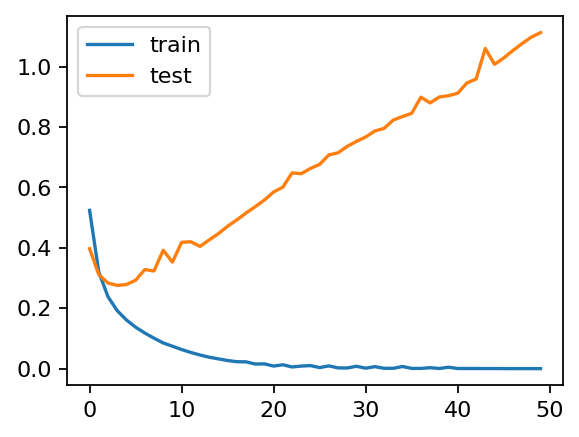

In [10]:
# Evaluamos el modelo
evaluate(model, history)

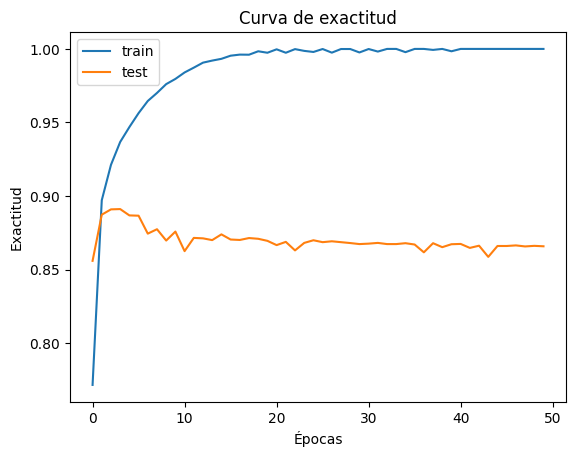

In [11]:
# Visualizemos las curvas de exactitud en el conjunto de entrenamiento y test
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="test")
plt.title("Curva de exactitud")
plt.xlabel("Épocas")
plt.ylabel("Exactitud")
plt.legend()
plt.show()

# Modelo con regularización L2

In [12]:
L2_regularizer = 0.1

# Definimos el modelo aplicando regularización
model1 = models.Sequential([
    layers.Dense(16, activation="relu", input_shape=(10000,),
                 kernel_regularizer=regularizers.l2(L2_regularizer)),
    layers.Dense(16, activation="relu",
                 kernel_regularizer=regularizers.l2(L2_regularizer)),
    layers.Dense(1, activation="sigmoid")
    ])

In [13]:
# Compilamos el modelo
model1.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [14]:
# Entrenamos el modelo
history1 = model1.fit(partial_x_train,
                    partial_y_train,
                    epochs = 50,
                    batch_size = 512,
                    validation_data = (x_val, y_val))

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.7197 - loss: 2.4619 - val_accuracy: 0.8231 - val_loss: 1.8318
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8083 - loss: 1.7058 - val_accuracy: 0.7935 - val_loss: 1.5933
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.8031 - loss: 1.4812 - val_accuracy: 0.7716 - val_loss: 1.3923
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8107 - loss: 1.2908 - val_accuracy: 0.8148 - val_loss: 1.2071
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8109 - loss: 1.1347 - val_accuracy: 0.8223 - val_loss: 1.0660
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8166 - loss: 1.0057 - val_accuracy: 0.8247 - val_loss: 0.9523
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8193 - loss: 0.9033 - val_accuracy: 0.7944 - val_loss: 0.8670
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.8177 - loss: 0.8225 - val_accuracy: 0.8234 - v

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8750 - loss: 0.5050
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8567 - loss: 0.5291
Trainining accuracy: 0.88
Testing accuracy: 0.86


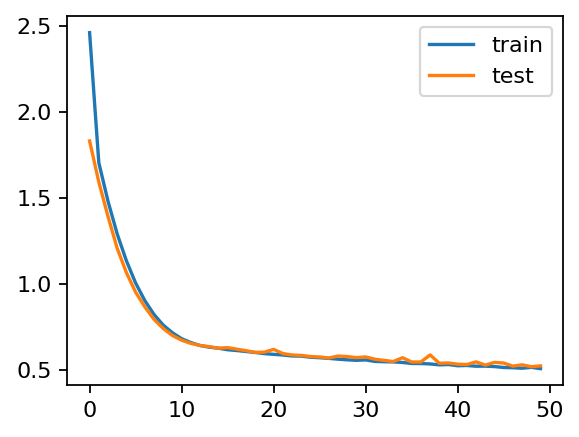

In [15]:
# Evaluamos el modelo con la regularización
evaluate(model1, history1)

# Añadiendo DropOut

In [16]:
import numpy as np
import tensorflow
from tensorflow import keras
from tensorflow.keras import layers
from keras_tuner import RandomSearch

def build_model(hp):
    dropout_rate = hp.Float('dropout_rate', min_value=0.1, max_value= 0.6, step = 0.1)
    model2 = keras.Sequential([
        layers.Dense(16, activation="relu", input_shape=(10000,)),
        layers.Dropout(dropout_rate),
        layers.Dense(16, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation="sigmoid")
    ])

    model2.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
    return model2

In [17]:
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=2,
    directory='my_dir1',
    project_name='dropout_tuning'
)

# Hacemos la búsqueda del hiperparámetro
tuner.search(partial_x_train,
             partial_y_train,
             epochs=50,
             validation_data=(x_val, y_val),
             callbacks=[tensorflow.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)])


Trial 5 Complete [00h 01m 09s]
val_accuracy: 0.8826000094413757

Best val_accuracy So Far: 0.8903999924659729
Total elapsed time: 00h 05m 34s


In [18]:
best_hyperparams = tuner.get_best_hyperparameters(num_trials=2)[0]
print(f"Mejor tasa de DropOut: {best_hyperparams.get('dropout_rate')}")


Mejor tasa de DropOut: 0.1


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 8 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


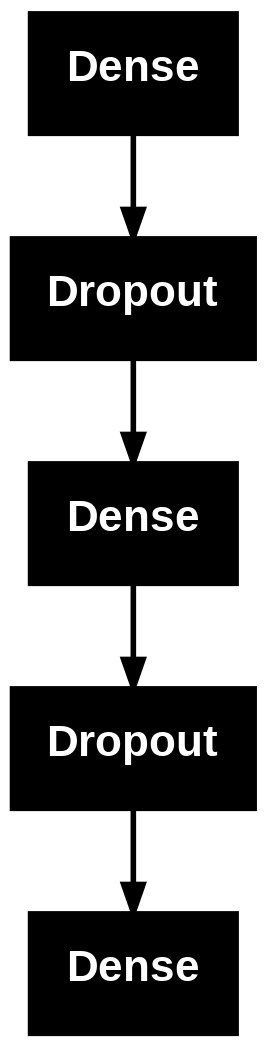

In [19]:
import tensorflow as tf
best_model = tuner.get_best_models(num_models=1)[0]
tf.keras.utils.plot_model(best_model)


In [20]:
# Entrenamos el mdejor modelo
history2 = best_model.fit(partial_x_train,
                          partial_y_train,
                          epochs = 50,
                          batch_size = 512,
                          validation_data = (x_val, y_val))

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.9216 - loss: 0.2151 - val_accuracy: 0.8866 - val_loss: 0.2789
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9399 - loss: 0.1768 - val_accuracy: 0.8861 - val_loss: 0.2833
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9480 - loss: 0.1528 - val_accuracy: 0.8887 - val_loss: 0.2871
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9597 - loss: 0.1266 - val_accuracy: 0.8865 - val_loss: 0.2978
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9673 - loss: 0.1074 - val_accuracy: 0.8827 - val_loss: 0.3251
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9746 - loss: 0.0887 - val_accuracy: 0.8809 - val_loss: 0.3473
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9790 - loss: 0.0763 - val_accuracy: 0.8780 - val_loss: 0.3786
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9837 - loss: 0.0633 - val_accuracy: 0.8796 - v

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9495 - loss: 0.4587
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8608 - loss: 1.2347
Trainining accuracy: 0.95
Testing accuracy: 0.86


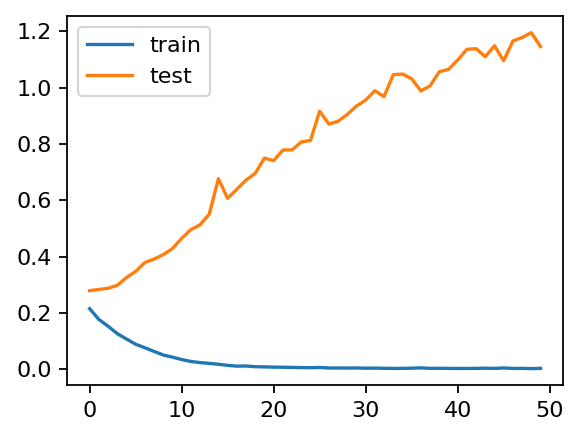

In [21]:
evaluate(best_model, history2)

# DropOut y Regularización L2

In [22]:
def build_model(hp):
  dropout_rate = hp.Float('dropout_rate', min_value=0.1, max_value =0.6, step = 0.1)
  L2_regularization = hp.Float('L2_regularization', min_value=0.01, max_value= 0.1, step =0.01)
  model3 = keras.Sequential([
      layers.Dense(16, activation="relu", input_shape=(10000,),kernel_regularizer=regularizers.l2(L2_regularization)),
      layers.Dropout(dropout_rate),
      layers.Dense(16, activation="relu",kernel_regularizer=regularizers.l2(L2_regularization)),
      layers.Dropout(dropout_rate),
      layers.Dense(1, activation="sigmoid")
  ])
  model3.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
  return model3

In [23]:
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='my_dir2',
    project_name='dropout_l2_tuning'
)

tuner.search(partial_x_train,
             partial_y_train,
             epochs = 50,
             validation_data = (x_val, y_val),
             callbacks=[tensorflow.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)]
             )


Trial 10 Complete [00h 01m 46s]
val_accuracy: 0.8550000190734863

Best val_accuracy So Far: 0.8737999796867371
Total elapsed time: 00h 15m 16s


In [24]:
# Mostramos los mejores hiperparámetros y el mejor modelo
best_hyperparams1 = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Mejor tasa de DropOut: {best_hyperparams1.get('dropout_rate')}")
print(f"Mejor tasa de regularización L2: {best_hyperparams1.get('L2_regularization')}")

Mejor tasa de DropOut: 0.2
Mejor tasa de regularización L2: 0.01


In [25]:
# Definimos el modelo con los mejores hiperparámetros del RandomSearch
L2_regularizer = best_hyperparams1.get('L2_regularization')
dropout_rate = best_hyperparams1.get('dropout_rate')

model3 = models.Sequential([
    layers.Dense(16, activation="relu", input_shape=(10000,), kernel_regularizer=regularizers.l2(L2_regularizer)),
    layers.Dropout(dropout_rate),
    layers.Dense(16, activation="relu", kernel_regularizer=regularizers.l2(L2_regularizer)),
    layers.Dropout(dropout_rate),
    layers.Dense(1, activation="sigmoid")
])

# Compilar el modelo
model3.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

# Entrenamos el modelo
history3 = model3.fit(partial_x_train,
                      partial_y_train,
                      batch_size = 512,
                      epochs = 50,
                      validation_data= (x_val, y_val))

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.7282 - loss: 0.8529 - val_accuracy: 0.8568 - val_loss: 0.6592
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.8279 - loss: 0.6336 - val_accuracy: 0.8556 - val_loss: 0.5827
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.8523 - loss: 0.5660 - val_accuracy: 0.8695 - val_loss: 0.5256
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.8634 - loss: 0.5310 - val_accuracy: 0.8692 - val_loss: 0.5112
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.8736 - loss: 0.4982 - val_accuracy: 0.8728 - val_loss: 0.4846
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8767 - loss: 0.4782 - val_accuracy: 0.8744 - val_loss: 0.4709
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8781 - loss: 0.4624 - val_accuracy: 0.8782 - val_loss: 0.4578
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8857 - loss: 0.4453 - val_accuracy: 0.8796 - v

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9300 - loss: 0.3119
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8777 - loss: 0.4141
Trainining accuracy: 0.93
Testing accuracy: 0.88


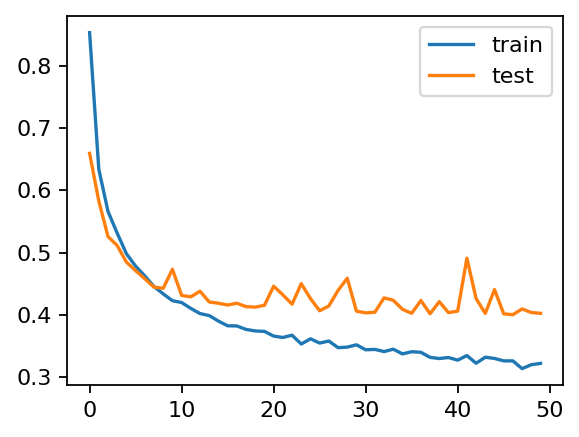

In [26]:
# Evaluamos el modelo
evaluate(model3, history3)

In [27]:
# Definimos el modelo con DroOut = 0.3, L2 = 0.001
L2_regularizer = 0.01
dropout_rate = 0.3

model4 = models.Sequential([
    layers.Dense(16, activation="relu", input_shape=(10000,), kernel_regularizer=regularizers.l2(L2_regularizer)),
    layers.Dropout(dropout_rate),
    layers.Dense(16, activation="relu", kernel_regularizer=regularizers.l2(L2_regularizer)),
    layers.Dropout(dropout_rate),
    layers.Dense(1, activation="sigmoid")
])

# Compilar el modelo
model4.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

# Entrenamos el modelo
history4 = model4.fit(partial_x_train,
                      partial_y_train,
                      batch_size = 512,
                      epochs = 50,
                      validation_data= (x_val, y_val))

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.6981 - loss: 0.8735 - val_accuracy: 0.8474 - val_loss: 0.6687
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8205 - loss: 0.6426 - val_accuracy: 0.8318 - val_loss: 0.5876
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.8559 - loss: 0.5664 - val_accuracy: 0.8765 - val_loss: 0.5104
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8677 - loss: 0.5256 - val_accuracy: 0.8747 - val_loss: 0.4921
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.8786 - loss: 0.4978 - val_accuracy: 0.8777 - val_loss: 0.4714
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.8828 - loss: 0.4762 - val_accuracy: 0.8792 - val_loss: 0.4612
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8922 - loss: 0.4516 - val_accuracy: 0.8816 - val_loss: 0.4470
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8914 - loss: 0.4405 - val_accuracy: 0.8802 - v

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9287 - loss: 0.3154
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8725 - loss: 0.4235
Trainining accuracy: 0.93
Testing accuracy: 0.87


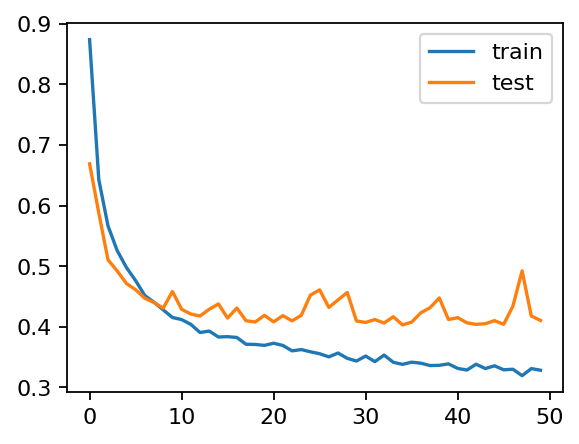

In [28]:
evaluate(model4, history4)

# Aplicando EarlyStopping

In [29]:
# Modelo con EarlyStopping
modelo5 = models.Sequential([
    layers.Dense(16, activation="relu", input_shape=(10000,)),
    layers.Dropout(0.5),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])
# Compilar el modelo
modelo5.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

# Configurar el Earlystopping
early_stopping = tensorflow.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# Entrenar el modelo
history5 = modelo5.fit(partial_x_train,
                       partial_y_train,
                       epochs = 50,
                       batch_size = 512,
                       validation_data = (x_val, y_val),
                       callbacks=[early_stopping])


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.5999 - loss: 0.6553 - val_accuracy: 0.8267 - val_loss: 0.5843
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.7449 - loss: 0.5616 - val_accuracy: 0.8640 - val_loss: 0.4911
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8136 - loss: 0.4853 - val_accuracy: 0.8779 - val_loss: 0.4211
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8505 - loss: 0.4224 - val_accuracy: 0.8755 - val_loss: 0.3669
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8721 - loss: 0.3712 - val_accuracy: 0.8869 - val_loss: 0.3181
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8930 - loss: 0.3273 - val_accuracy: 0.8911 - val_loss: 0.3019
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9069 - loss: 0.2923 - val_accuracy: 0.8917 - val_loss: 0.2849
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9163 - loss: 0.2607 - val_accuracy: 0.8815 - v

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9406 - loss: 0.1763
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8807 - loss: 0.3355
Trainining accuracy: 0.94
Testing accuracy: 0.88


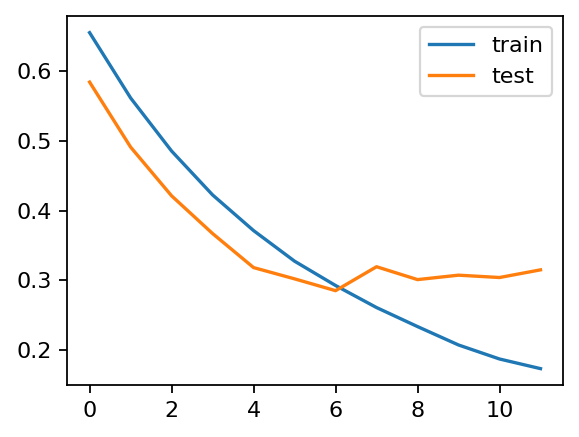

In [30]:
evaluate(modelo5, history5)

# Usando DropOut, L2 y Earlystopping

In [31]:
# Definimos el modelo con DroOut = 0.3, L2 = 0.001
L2_regularizer = 0.1
dropout_rate = 0.2

model6 = models.Sequential([
    layers.Dense(16, activation="relu", input_shape=(10000,), kernel_regularizer=regularizers.l2(L2_regularizer)),
    layers.Dropout(dropout_rate),
    layers.Dense(16, activation="relu", kernel_regularizer=regularizers.l2(L2_regularizer)),
    layers.Dropout(dropout_rate),
    layers.Dense(1, activation="sigmoid")
])

# Compilar el modelo
model6.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

# Configurar el Earlystopping
early_stopping = tensorflow.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

# Entrenamos el modelo
history6 = model6.fit(partial_x_train,
                      partial_y_train,
                      batch_size = 512,
                      epochs = 50,
                      validation_data= (x_val, y_val),
                      callbacks=[early_stopping])

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.6491 - loss: 2.3909 - val_accuracy: 0.7492 - val_loss: 1.7623
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.7345 - loss: 1.6509 - val_accuracy: 0.7784 - val_loss: 1.5257
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7527 - loss: 1.4329 - val_accuracy: 0.7631 - val_loss: 1.3436
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7515 - loss: 1.2527 - val_accuracy: 0.7823 - val_loss: 1.1662
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7545 - loss: 1.1038 - val_accuracy: 0.8190 - val_loss: 1.0344
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7639 - loss: 0.9811 - val_accuracy: 0.8301 - val_loss: 0.9223
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7619 - loss: 0.8862 - val_accuracy: 0.8243 - val_loss: 0.8427
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7651 - loss: 0.8142 - val_accuracy: 0.8036 - v

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8651 - loss: 0.5351
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8514 - loss: 0.5520
Trainining accuracy: 0.87
Testing accuracy: 0.85


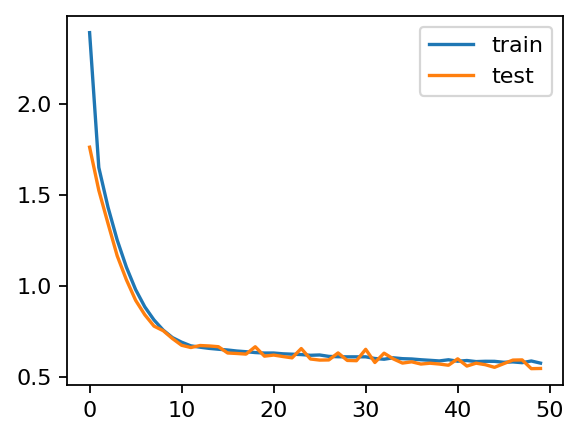

In [32]:
evaluate(model6, history6)